# Przewodnik po projekcie PDEProject

Ten notatnik prowadzi krok po kroku przez caly projekt:
1. Struktura plikow
2. Konfiguracja i srodowisko
3. Solver deterministyczny (PDE / FTCS)
4. Solver stochastyczny (Biased Brownian)
5. Porownanie wynikow
6. Uruchamianie pelnej animacji

Notebook zaklada, ze uruchamiasz go z katalogu glownego projektu.

In [1]:
from pathlib import Path

root = Path.cwd()
print(f'Katalog roboczy: {root}')

def print_tree(base: Path, max_depth: int = 2, prefix: str = '') -> None:
    if max_depth < 0:
        return
    entries = sorted(base.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for entry in entries:
        marker = '/' if entry.is_dir() else ''
        print(f'{prefix}- {entry.name}{marker}')
        if entry.is_dir():
            print_tree(entry, max_depth=max_depth - 1, prefix=prefix + '  ')

print('\nStruktura (do 2 poziomow):')
print_tree(root, max_depth=2)

Katalog roboczy: /media/Nowy/PDEProject

Struktura (do 2 poziomow):
- .venv/
  - bin/
    - activate
    - activate.csh
    - activate.fish
    - Activate.ps1
    - debugpy
    - debugpy-adapter
    - f2py
    - fonttools
    - ipython
    - ipython3
    - jupyter
    - jupyter-kernel
    - jupyter-kernelspec
    - jupyter-migrate
    - jupyter-run
    - jupyter-troubleshoot
    - numpy-config
    - pip
    - pip3
    - pip3.14
    - pyftmerge
    - pyftsubset
    - pygmentize
    - python
    - python3
    - python3.14
    - ttx
    - 𝜋thon
  - include/
  - lib/
    - python3.14/
  - lib64/
    - python3.14/
  - share/
    - jupyter/
    - man/
  - .gitignore
  - pyvenv.cfg
- .vscode/
  - settings.json
- heat_sim/
  - __pycache__/
    - __init__.cpython-314.pyc
    - brownian_solver.cpython-314.pyc
    - config.cpython-314.pyc
    - environment.cpython-314.pyc
    - pde_solver.cpython-314.pyc
    - visualizer.cpython-314.pyc
  - __init__.py
  - brownian_solver.py
  - config.py
  - env

## Import najwazniejszych klas

W projekcie masz piec glownych elementow:
- `SimulationConfig` - wszystkie parametry symulacji
- `EnvironmentGrid` - maska zrodla i operacje na siatce
- `PDESolver` - rozwiazywanie rownania ciepla FTCS
- `BrownianSolver` - ruch czastek i depozycja energii
- `SimulationVisualizer` - animacja porownawcza

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from heat_sim import (
    SimulationConfig,
    EnvironmentGrid,
    PDESolver,
    BrownianSolver,
    SimulationVisualizer,
)

np.set_printoptions(precision=3, suppress=True)
print('Import OK')

Import OK


## Krok 1: Konfiguracja i geometria zrodla

Tworzymy mala konfiguracje testowa, aby szybciej zobaczyc wyniki.

In [3]:
cfg = SimulationConfig(
    nx=80,
    ny=60,
    alpha=0.22,
    cooling_k=0.015,
    t_min=20.0,
    t_source=100.0,
    source_width=12,
    source_height=6,
)

print(cfg)
print('source_bounds (rows, cols):', cfg.source_bounds)

SimulationConfig(nx=80, ny=60, dx=1.0, dy=1.0, alpha=0.22, cooling_k=0.015, t_min=20.0, t_source=100.0, source_width=12, source_height=6)
source_bounds (rows, cols): (slice(52, 58, None), slice(34, 46, None))


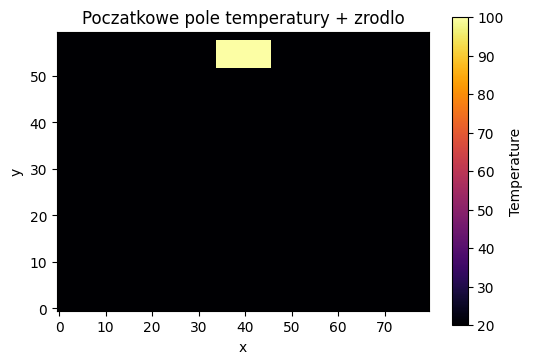

In [4]:
env = EnvironmentGrid(cfg)
field = env.create_temperature_field()

plt.figure(figsize=(6, 4))
plt.title('Poczatkowe pole temperatury + zrodlo')
plt.imshow(field, origin='lower', cmap='inferno', vmin=cfg.t_min, vmax=cfg.t_source)
plt.colorbar(label='Temperature')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Krok 2: Solver PDE (deterministyczny)

`PDESolver` oblicza stabilny krok czasowy `dt` z warunku CFL i wykonuje kroki FTCS.

PDE dt = 1.022727


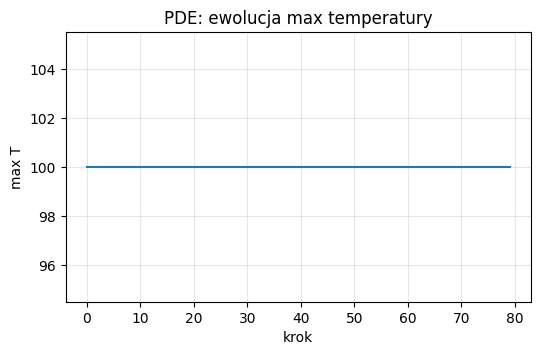

In [5]:
pde_solver = PDESolver(EnvironmentGrid(cfg), cfl_safety=0.9)
print(f'PDE dt = {pde_solver.dt:.6f}')

pde_max = []
for _ in range(80):
    pde_solver.step()
    pde_max.append(float(pde_solver.temperature.max()))

plt.figure(figsize=(6, 3.5))
plt.title('PDE: ewolucja max temperatury')
plt.plot(pde_max)
plt.xlabel('krok')
plt.ylabel('max T')
plt.grid(alpha=0.3)
plt.show()

## Krok 3: Solver Browna (stochastyczny)

`BrownianSolver` emituje czastki ze zrodla, przesuwa je po gradiencie temperatury + szumie i deponuje energie w siatce.

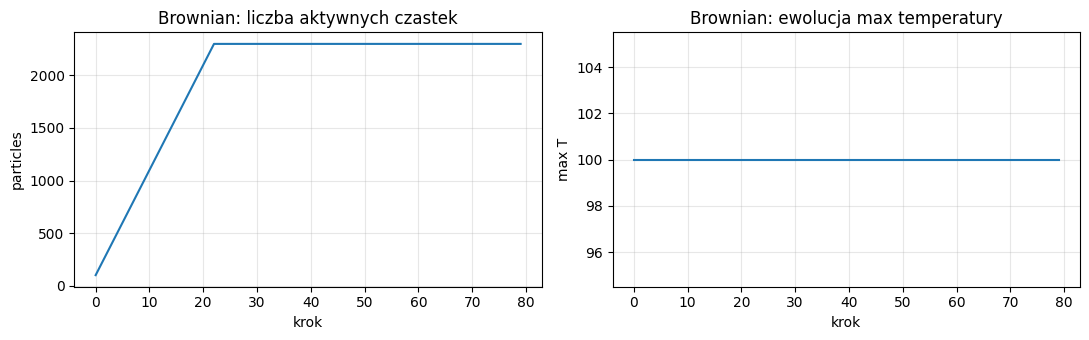

In [6]:
brownian_solver = BrownianSolver(
    environment=EnvironmentGrid(cfg),
    dt=pde_solver.dt,
    emit_count=100,
    particle_energy=1.8,
    deposit_fraction=0.16,
    particle_cutoff=0.03,
    mobility=0.4,
    diffusion=0.85,
    seed=42,
)

particle_counts = []
brownian_max = []
for _ in range(80):
    brownian_solver.step()
    particle_counts.append(brownian_solver.active_particles)
    brownian_max.append(float(brownian_solver.temperature.max()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].set_title('Brownian: liczba aktywnych czastek')
axes[0].plot(particle_counts)
axes[0].set_xlabel('krok')
axes[0].set_ylabel('particles')
axes[0].grid(alpha=0.3)

axes[1].set_title('Brownian: ewolucja max temperatury')
axes[1].plot(brownian_max)
axes[1].set_xlabel('krok')
axes[1].set_ylabel('max T')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Krok 4: Bezposrednie porownanie map temperatur

Uruchamiamy oba solvery przez te sama liczbe krokow i porownujemy pola temperatury obok siebie.

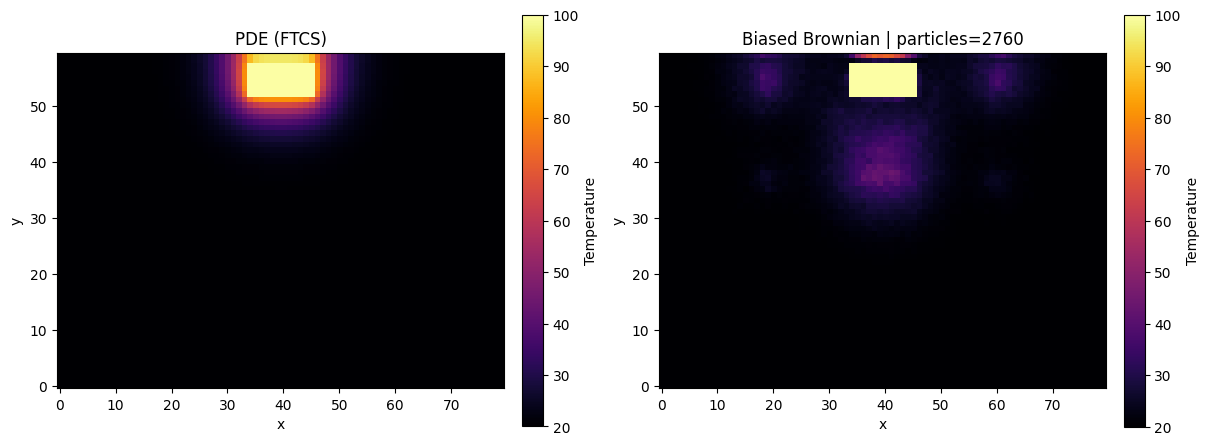

In [7]:
pde = PDESolver(EnvironmentGrid(cfg))
bro = BrownianSolver(EnvironmentGrid(cfg), dt=pde.dt, seed=123)

n_steps = 120
for _ in range(n_steps):
    pde.step()
    bro.step()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
vmin, vmax = cfg.t_min, cfg.t_source

im0 = axes[0].imshow(pde.temperature, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[0].set_title('PDE (FTCS)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im1 = axes[1].imshow(bro.temperature, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Biased Brownian | particles={bro.active_particles}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Temperature')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Temperature')
plt.show()

## Krok 5: Pelna animacja (jak w `main.py`)

Nizej masz komorke do uruchomienia tej samej logiki co w aplikacji CLI.
Domyslnie pokazuje okno i nie zapisuje GIF.

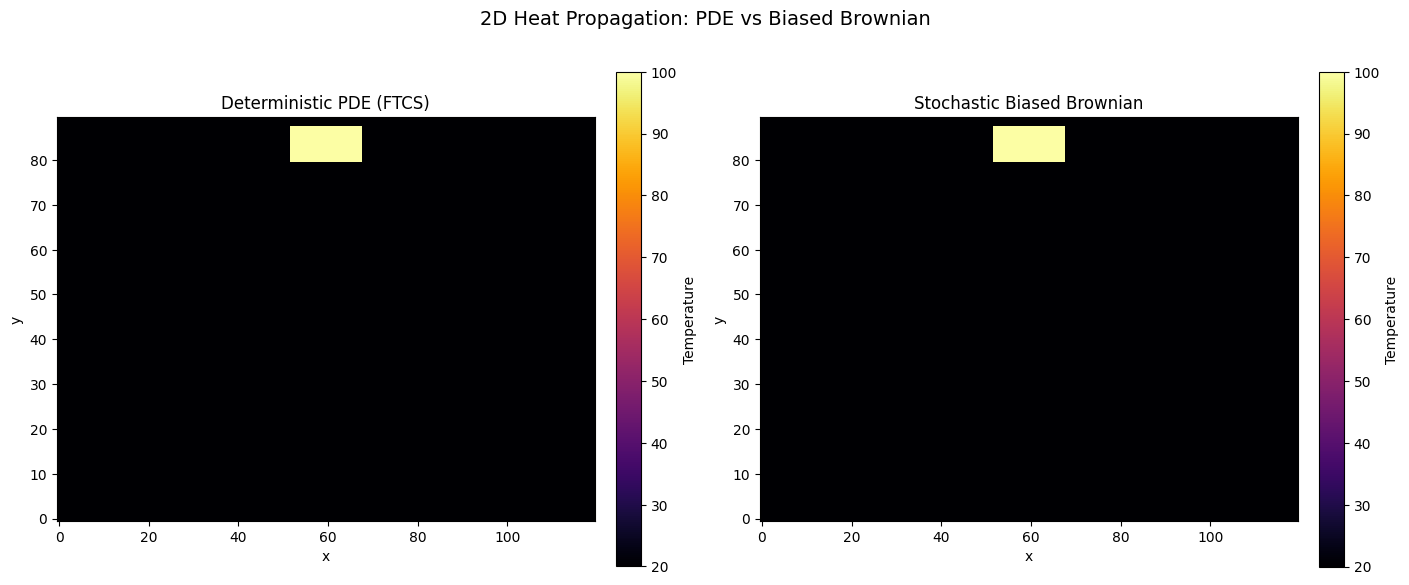

In [8]:
cfg_full = SimulationConfig(nx=120, ny=90)

pde_full = PDESolver(EnvironmentGrid(cfg_full), cfl_safety=0.9)
brown_full = BrownianSolver(
    environment=EnvironmentGrid(cfg_full),
    dt=pde_full.dt,
    emit_count=120,
    particle_energy=1.8,
    deposit_fraction=0.16,
    particle_cutoff=0.03,
    mobility=0.4,
    diffusion=0.85,
    seed=42,
)

viz = SimulationVisualizer(
    pde_solver=pde_full,
    brownian_solver=brown_full,
    frames=200,
    steps_per_frame=1,
    interval_ms=35,
)

# Ustaw save_gif_path='outputs/simulation.gif', aby zapisac animacje.
viz.run(save_gif_path=None, gif_fps=20, gif_dpi=110, show_window=True)

## Krok 6: Mapa projektu i co dalej

Powiazanie z plikami:
- `heat_sim/config.py` -> parametry i source_bounds
- `heat_sim/environment.py` -> maska zrodla + cooling Newtona
- `heat_sim/pde_solver.py` -> Laplasjan i FTCS
- `heat_sim/brownian_solver.py` -> emisja, dryf gradientowy, depozycja
- `heat_sim/visualizer.py` -> animacja side-by-side
- `main.py` -> interfejs CLI

Proponowane eksperymenty:
1. Zmien `cooling_k` i zobacz jak szybko pojawia sie stan ustalony.
2. Zwieksz `emit_count` i porownaj z PDE.
3. Zmien `mobility` i `diffusion`, aby kontrolowac ruch czastek.
4. Zapisz GIF i porownaj kilka konfiguracji obok siebie.